# 3. SBI Model Comparison: BE vs SC

Fit Boundary Estimation (BE) and Stimulus Category (SC) models to real
behavioural data via simulation-based inference (SNPE). Compare model fits
using held-out data.

### Structure

| Section | What | Cost |
|---------|------|------|
| 1–3 | Config, data loading, train/test split | seconds |
| 4 | Timing estimate (run before committing!) | ~1 min |
| **5** | **Multi-session SBIFitter (primary)** | **10–60 min per model** |
| 6 | Posterior parameter distributions | seconds |
| 7 | Held-out evaluation (session-level + within-session) | minutes |
| 8 | Posterior predictive check (training data) | minutes |
| 9 | Per-session quick comparison (optional sanity check) | ~5 min |
| 10–11 | Multi-animal loop and group summary | hours |

### Relationship to manuscript

The published approach used grid search + 2-fold CV repeated 64 times on update
matrix MSE. Here we replace grid search with SNPE (full posteriors, not point
estimates) and use a temporal train/test split that respects session ordering.

In [83]:
def evaluate_on_heldout_sessions(
    fitter: SBIFitter, result: Any,
    test_fd: FittingData, stat_names: List[str],
    n_sim_reps: int = 50, n_bins: int = 8,
) -> Dict[str, Any]:
    """
    Evaluate fitted model on held-out sessions.

    Uses last-training-session posterior params to simulate on
    test stimuli. Compares per-session stat MSE and pooled UM MSE.
    """
    session_params = fitter.extract_session_params(result, n_samples=2000)
    last_params = session_params[-1]

    creator = create_be_simulator if fitter.model_type == 'be' else create_sc_simulator

    # Observed stats per test session
    obs_stats = []
    for i in range(test_fd.n_sessions):
        v = ~test_fd.no_response[i]
        obs_stats.append(compute_summary_stats(
            test_fd.choices[i][v], test_fd.stimuli[i][v], test_fd.categories[i][v],
            stat_names=stat_names, return_dict=False,
        ))

    # Observed pooled UM
    pooled = test_fd.pool()
    obs_um, _, _ = compute_update_matrix(
        pooled['stimuli'], pooled['choices'], pooled['categories'], n_bins=n_bins,
    )

    # Simulate
    sim_stats = {i: [] for i in range(test_fd.n_sessions)}
    sim_ums = []

    for rep in range(n_sim_reps):
        all_choices = []
        for i in range(test_fd.n_sessions):
            v = ~test_fd.no_response[i]
            sim = creator(
                test_fd.stimuli[i][v], test_fd.categories[i][v],
                fixed_params=last_params, stat_names=stat_names,
                burn_in=fitter.burn_in,
            )
            try:
                stats, choices = sim.simulate(
                    sim.sample_prior(seed=rep * 100 + i),
                    seed=rep * 100 + i, return_choices=True,
                )
                if not np.any(np.isnan(stats)):
                    sim_stats[i].append(stats)
                all_choices.append(choices.flatten())
            except Exception:
                continue

        if len(all_choices) == test_fd.n_sessions:
            try:
                sim_um, _, _ = compute_update_matrix(
                    pooled['stimuli'], np.concatenate(all_choices),
                    pooled['categories'], n_bins=n_bins,
                )
                if not np.all(np.isnan(sim_um)):
                    sim_ums.append(sim_um)
            except Exception:
                pass

    # Metrics
    stat_mses = []
    for i in range(test_fd.n_sessions):
        if sim_stats[i]:
            m = np.nanmean(sim_stats[i], axis=0)
            stat_mses.append(np.nanmean((m - obs_stats[i]) ** 2))

    mean_um = np.nanmean(sim_ums, axis=0) if sim_ums else None
    um_mse = matrix_error(mean_um, obs_um) if mean_um is not None else np.nan

    return {
        'stat_mses': stat_mses,
        'mean_stat_mse': np.nanmean(stat_mses) if stat_mses else np.nan,
        'um_mse': um_mse,
        'obs_um': obs_um, 'sim_mean_um': mean_um,
        'n_valid_ums': len(sim_ums),
    }

In [1]:
%matplotlib inline

import os, sys
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import time
from typing import Dict, List, Tuple, Optional, Any

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

from behav_utils.data.structures import (
    ExperimentData, AnimalData, SessionData, FittingData,
)
from behav_utils.data.loading import load_experiment
from behav_utils.analysis.summary_stats import (
    compute_summary_stats, flatten_stats, get_stat_names_expanded,
    list_available_stats, DEFAULT_STATS, FEATURE_MATRIX_STATS,
)
from behav_utils.analysis.update_matrix import compute_update_matrix, matrix_error
from behav_utils.plotting.update_matrix import (
    plot_update_matrix, plot_update_matrix_comparison, plot_update_matrix_summary,
)

from Inference.sbi_fitter import (
    SBIFitter, ConstantLink, GPLink,
    DEFAULT_BE_PARAM_LINKS, DEFAULT_SC_PARAM_LINKS,
)
from Inference.simulator import (
    Simulator, SimulatorConfig, ModelType,
    create_be_simulator, create_sc_simulator,
    get_sbi_prior, wrap_for_sbi,
)

try:
    import torch
    from sbi.inference import SNPE
    SBI_AVAILABLE = True
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"SBI available. torch={torch.__version__}, device={device}")
except ImportError as e:
    SBI_AVAILABLE = False
    print(f"SBI not available: {e}\nInstall with: pip install sbi torch")

SBI available. torch=2.5.1, device=cpu


---
## 1. Configuration

**Edit this cell to control the entire notebook.** Everything downstream reads from these variables.

In [62]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  PATHS                                                              ║
# ╚═══════════════════════════════════════════════════════════════════════╝
CONFIG_PATH = '/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/config.yaml'

# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  SESSION SELECTION                                                  ║
# ╚═══════════════════════════════════════════════════════════════════════╝
STAGE = 'Full_Task_Cont'
DISTRIBUTION = 'Uniform'          # None = all distributions
MIN_VALID_TRIALS = 30
TARGET_ANIMAL = None              # Single animal ID, or None = all
MIN_SESSIONS = 15                  # Skip animals with fewer sessions

# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  TRAIN / TEST SPLIT                                                 ║
# ║                                                                     ║
# ║  Session-level: hold out last fraction of sessions.                 ║
# ║  Within-session: hold out last N trials per training session.       ║
# ║  Set WITHIN_SESSION_HOLDOUT = 0 to disable.                        ║
# ╚═══════════════════════════════════════════════════════════════════════╝
HOLDOUT_FRACTION = 0.1            # Fraction of sessions (min 2)
WITHIN_SESSION_HOLDOUT = 50       # Trials per session (0 = off)

# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  SUMMARY STATISTICS                                                 ║
# ║                                                                     ║
# ║  Controls the SBI observation vector. Pick a preset OR define a     ║
# ║  custom list. The timing cell (§4) shows the cost of each choice.   ║
# ║                                                                     ║
# ║  PRESETS:                                                           ║
# ║    'full'   → all FEATURE_MATRIX_STATS  (127 dims/session, SLOW)   ║
# ║    'core'   → accuracy, psychometric, recency, win_stay,           ║
# ║               stimulus_sensitivity      (8 dims/session, FAST)     ║
# ║    'mid'    → core + sd_profile + logistic_history + lose_shift    ║
# ║               + hard_easy_ratio         (23 dims/session)          ║
# ║    'custom' → uses CUSTOM_STATS list below                         ║
# ╚═══════════════════════════════════════════════════════════════════════╝
STAT_PRESET = 'custom'

CUSTOM_STATS = [
    'accuracy', 'psychometric', 'psychometric_gof',
	'recency', 'stimulus_recency', 'win_stay', 'lose_shift',
	'stimulus_sensitivity', 'hard_easy_ratio',
	'logistic_history', 'update_matrix']

_STAT_PRESETS = {
    'full': list(FEATURE_MATRIX_STATS),
    'core': ['accuracy', 'psychometric', 'recency', 'win_stay',
             'stimulus_sensitivity'],
    'mid':  ['accuracy', 'psychometric', 'psychometric_gof',
             'recency', 'stimulus_recency', 'win_stay', 'lose_shift',
             'stimulus_sensitivity', 'hard_easy_ratio',
             'sd_profile', 'logistic_history'],
    'custom': CUSTOM_STATS,
}
SBI_STAT_NAMES = _STAT_PRESETS[STAT_PRESET]

# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  GP-LINKED PARAMETERS                                              ║
# ║                                                                     ║
# ║  Which params vary across sessions (GP prior). All others are       ║
# ║  constant. Set to None = ALL params vary (default).                 ║
# ╚═══════════════════════════════════════════════════════════════════════╝
BE_VARYING_PARAMS = None  # None = all; or e.g. ['eta_learning', 'eta_relax']
SC_VARYING_PARAMS = None  # None = all; or e.g. ['gamma']
GP_LENGTHSCALE = 5.0
GP_AMPLITUDE = 0.1

# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  SBI TRAINING                                                       ║
# ╚═══════════════════════════════════════════════════════════════════════╝
N_SBI_SIMS = 10_000       # 10k debug, 50k+ real
N_POSTERIOR_SAMPLES = 2000
BURN_IN = 1000
SEED = 42

# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  PLOTTING                                                           ║
# ╚═══════════════════════════════════════════════════════════════════════╝
BE_COLOUR = 'steelblue'
SC_COLOUR = 'darkorange'
N_BINS = 8

In [63]:
# ── Stat dimension summary ────────────────────────────────────────────
stat_labels = get_stat_names_expanded(SBI_STAT_NAMES)
n_dims_per_session = len(stat_labels)

print(f"Preset: '{STAT_PRESET}'")
print(f"Stats ({len(SBI_STAT_NAMES)} groups → {n_dims_per_session} dims per session):")
for name in SBI_STAT_NAMES:
    n = len(get_stat_names_expanded([name]))
    print(f"  {name:35s} → {n:3d} dims")
print(f"\nWith ~15 training sessions → ~{n_dims_per_session * 15} total observation dims")

Preset: 'custom'
Stats (11 groups → 84 dims per session):
  accuracy                            →   1 dims
  psychometric                        →   4 dims
  psychometric_gof                    →   1 dims
  recency                             →   1 dims
  stimulus_recency                    →   1 dims
  win_stay                            →   1 dims
  lose_shift                          →   1 dims
  stimulus_sensitivity                →   1 dims
  hard_easy_ratio                     →   1 dims
  logistic_history                    →   8 dims
  update_matrix                       →  64 dims

With ~15 training sessions → ~1260 total observation dims


---
## 2. Load data and select Uniform expert sessions

In [64]:
experiment = load_experiment(CONFIG_PATH)

print(f"Loaded {experiment.n_animals} animals:\n")
for animal_name in experiment.animals:
    animal = experiment.get_animal(animal_name)
    sessions = animal.get_sessions(stage=STAGE, distribution=DISTRIBUTION)
    n = len(sessions)
    total_trials = sum(
        (~s.trials.get_arrays()['no_response']).sum() for s in sessions
    ) if sessions else 0
    flag = ' ok' if n >= MIN_SESSIONS else ' (too few)'
    print(f"  {animal.animal_id}: {n} sessions, ~{total_trials} valid trials{flag}")

Loaded 12 animals, 433 total sessions
Loaded 12 animals:

  SS01: 43 sessions, ~20643 valid trials ok
  SS02: 4 sessions, ~1329 valid trials (too few)
  SS04: 50 sessions, ~19395 valid trials ok
  SS05: 34 sessions, ~10425 valid trials ok
  SS06: 34 sessions, ~9247 valid trials ok
  SS07: 34 sessions, ~9735 valid trials ok
  SS08: 38 sessions, ~15783 valid trials ok
  SS09: 25 sessions, ~7853 valid trials ok
  SS10: 32 sessions, ~8080 valid trials ok
  SS11: 28 sessions, ~6959 valid trials ok
  SS12: 13 sessions, ~4150 valid trials (too few)
  SS13: 28 sessions, ~6360 valid trials ok


In [65]:
if TARGET_ANIMAL:
    animals_to_fit = [experiment.get_animal(TARGET_ANIMAL)]
else:
    animals_to_fit = [
        experiment.get_animal(a) for a in experiment.animals
        if len(experiment.get_animal(a).get_sessions(stage=STAGE, distribution=DISTRIBUTION)) >= MIN_SESSIONS
    ]
print(f"Animals to fit: {[a.animal_id for a in animals_to_fit]}")

Animals to fit: ['SS01', 'SS04', 'SS05', 'SS06', 'SS07', 'SS08', 'SS09', 'SS10', 'SS11', 'SS13']


---
## 3. Train / test split

Two holdout strategies (both computed here, used in different evaluation sections):

1. **Session-level** (§7a): last 20% of sessions held out. Tests whether fitted
   parameters predict *future* sessions.
2. **Within-session** (§7b): last N trials of each training session held out.
   Tests whether the model predicts behaviour *later in the same session*.

In [66]:
def split_fitting_data(
    animal: AnimalData,
    stage: str, distribution: str,
    holdout_fraction: float,
    within_session_holdout: int,
    min_valid_trials: int,
) -> Dict[str, Any]:
    """
    Build train/test FittingData for one animal.

    Returns dict with:
        'train': FittingData (full training sessions)
        'test':  FittingData (held-out sessions)
        'train_truncated': FittingData (training sessions with last N trials removed)
        'train_heldout_trials': list of dicts with held-out trial arrays
    """
    full_data = animal.get_fitting_data(
        stage=stage, distribution=distribution,
        min_valid_trials=min_valid_trials,
    )
    n_total = full_data.n_sessions
    n_test = max(2, int(np.ceil(n_total * holdout_fraction)))
    n_train = n_total - n_test

    if n_train < 3:
        raise ValueError(
            f"Only {n_total} sessions; after holding out {n_test}, "
            f"only {n_train} remain (need >= 3)."
        )

    def _slice_fd(fd, start, end):
        n = end - start
        return FittingData(
            animal_id=fd.animal_id,
            session_ids=fd.session_ids[start:end],
            session_dates=fd.session_dates[start:end],
            session_indices=fd.session_indices[start:end],
            stimuli=fd.stimuli[start:end],
            categories=fd.categories[start:end],
            choices=fd.choices[start:end],
            no_response=fd.no_response[start:end],
            not_blockstart=fd.not_blockstart[start:end],
            n_sessions=n,
            trials_per_session=fd.trials_per_session[start:end],
        )

    train_fd = _slice_fd(full_data, 0, n_train)
    test_fd = _slice_fd(full_data, n_train, n_total)

    # Within-session split
    train_truncated = None
    heldout_trials = None

    if within_session_holdout > 0:
        trunc_stim, trunc_cat, trunc_choice = [], [], []
        trunc_nr, trunc_nbs = [], []
        heldout_trials = []
        trunc_tps = []

        for i in range(n_train):
            n = len(train_fd.stimuli[i])
            cut = max(min_valid_trials, n - within_session_holdout)

            trunc_stim.append(train_fd.stimuli[i][:cut])
            trunc_cat.append(train_fd.categories[i][:cut])
            trunc_choice.append(train_fd.choices[i][:cut])
            trunc_nr.append(train_fd.no_response[i][:cut])
            nbs = np.ones(cut, dtype=bool)
            if cut > 0:
                nbs[0] = False
            trunc_nbs.append(nbs)
            trunc_tps.append(cut)

            valid_ho = ~train_fd.no_response[i][cut:]
            heldout_trials.append({
                'stimuli': train_fd.stimuli[i][cut:][valid_ho],
                'categories': train_fd.categories[i][cut:][valid_ho],
                'choices': train_fd.choices[i][cut:][valid_ho],
            })

        train_truncated = FittingData(
            animal_id=full_data.animal_id,
            session_ids=train_fd.session_ids,
            session_dates=train_fd.session_dates,
            session_indices=train_fd.session_indices,
            stimuli=trunc_stim, categories=trunc_cat, choices=trunc_choice,
            no_response=trunc_nr, not_blockstart=trunc_nbs,
            n_sessions=n_train,
            trials_per_session=np.array(trunc_tps),
        )

    return {
        'full': full_data, 'train': train_fd, 'test': test_fd,
        'train_truncated': train_truncated,
        'train_heldout_trials': heldout_trials,
        'n_train': n_train, 'n_test': n_test, 'n_total': n_total,
    }

In [67]:
test_animal = animals_to_fit[2]
split = split_fitting_data(
    test_animal, STAGE, DISTRIBUTION,
    HOLDOUT_FRACTION, WITHIN_SESSION_HOLDOUT, MIN_VALID_TRIALS,
)

print(f"Animal: {test_animal.animal_id}")
print(f"Total Uniform expert sessions: {split['n_total']}")
print(f"Train: {split['n_train']} sessions ({split['train'].trials_per_session.sum()} trials)")
print(f"Test:  {split['n_test']} sessions ({split['test'].trials_per_session.sum()} trials)")
if split['train_truncated'] is not None:
    held = [len(h['stimuli']) for h in split['train_heldout_trials']]
    print(f"Within-session holdout: {sum(held)} valid held-out trials "
          f"(~{np.mean(held):.0f}/session)")
print(f"Training trials/session: {split['train'].trials_per_session}")

Animal: SS05
Total Uniform expert sessions: 34
Train: 30 sessions (8899 trials)
Test:  4 sessions (1526 trials)
Within-session holdout: 1500 valid held-out trials (~50/session)
Training trials/session: [226 361 311 302 310 257 220 307 266 290 280 284 342 353 334 309 260 235
 379 344 325 238 221 191 355 368 342 355 314 220]


---
## 4. Timing estimate

**Run this before the full fit.** It simulates a few parameter sets and reports
how long each takes, so you can decide whether to adjust `STAT_PRESET` or `N_SBI_SIMS`.

In [68]:
def build_param_links(
    model_type: str,
    varying_params: Optional[List[str]] = None,
    lengthscale: float = 5.0,
    amplitude: float = 0.1,
) -> Dict[str, Any]:
    """Build param_links from config. None = all params vary."""
    defaults = DEFAULT_BE_PARAM_LINKS if model_type == 'be' else DEFAULT_SC_PARAM_LINKS
    order = SBIFitter.BE_PARAM_ORDER if model_type == 'be' else SBIFitter.SC_PARAM_ORDER
    if varying_params is None:
        varying_params = order
    links = {}
    for name in order:
        bounds = defaults[name].bounds
        if name in varying_params:
            links[name] = GPLink(bounds=bounds, lengthscale=lengthscale,
                                 amplitude=amplitude)
        else:
            links[name] = ConstantLink(bounds=bounds)
    return links


be_links = build_param_links('be', BE_VARYING_PARAMS, GP_LENGTHSCALE, GP_AMPLITUDE)
sc_links = build_param_links('sc', SC_VARYING_PARAMS, GP_LENGTHSCALE, GP_AMPLITUDE)

be_fitter = SBIFitter(
    split['train'], model_type='be', param_links=be_links,
    summary_stats=SBI_STAT_NAMES, burn_in=BURN_IN,
)
sc_fitter = SBIFitter(
    split['train'], model_type='sc', param_links=sc_links,
    summary_stats=SBI_STAT_NAMES, burn_in=BURN_IN,
)

print(be_fitter.describe())
print()
print(sc_fitter.describe())

SBIFitter Configuration
Model: BE
Animal: SS05
Sessions: 30
Trials per session: [226, 361, 311, 302, 310, 257, 220, 307, 266, 290, 280, 284, 342, 353, 334, 309, 260, 235, 379, 344, 325, 238, 221, 191, 355, 368, 342, 355, 314, 220]

Parameter links:
  sigma_percep: GPLink(0.05, 0.5), ls=5.0, amp=0.1
  A_repulsion: GPLink(0.0, 0.5), ls=5.0, amp=0.1
  eta_learning: GPLink(0.05, 0.9), ls=5.0, amp=0.1
  eta_relax: GPLink(0.01, 0.4), ls=5.0, amp=0.1

Theta dimensionality: 120
  Constant params: []
  Varying params: ['sigma_percep', 'A_repulsion', 'eta_learning', 'eta_relax']

Summary stats: ['accuracy', 'psychometric', 'psychometric_gof', 'recency', 'stimulus_recency', 'win_stay', 'lose_shift', 'stimulus_sensitivity', 'hard_easy_ratio', 'logistic_history', 'update_matrix']
Stats vector length: 2520
  Per session: 84

Burn-in: 1000 trials

SBIFitter Configuration
Model: SC
Animal: SS05
Sessions: 30
Trials per session: [226, 361, 311, 302, 310, 257, 220, 307, 266, 290, 280, 284, 342, 353, 334,

In [69]:
for name, fitter in [('BE', be_fitter), ('SC', sc_fitter)]:
    info = fitter.test_simulator(n_tests=5, seed=SEED)
    ms = info['mean_time_per_sim'] * 1000
    est = info['mean_time_per_sim'] * N_SBI_SIMS / 60
    nan_rate = np.mean([n > 0 for n in info['nan_counts']])
    print(f"{name}: {ms:.0f} ms/sim  |  {est:.1f} min for {N_SBI_SIMS:,} sims  |  "
          f"NaN rate: {nan_rate:.0%}  |  stat vector: {info['stats_dim']} dims")

print("\n" + "-" * 60)
print("If too slow → change STAT_PRESET to 'mid' or 'core' in section 1.")
print("If NaN rate > 30% → increase BURN_IN or check parameter bounds.")

BE: 1916 ms/sim  |  319.4 min for 10,000 sims  |  NaN rate: 0%  |  stat vector: 2520 dims
SC: 3475 ms/sim  |  579.1 min for 10,000 sims  |  NaN rate: 20%  |  stat vector: 2520 dims

------------------------------------------------------------
If too slow → change STAT_PRESET to 'mid' or 'core' in section 1.
If NaN rate > 30% → increase BURN_IN or check parameter bounds.


### 4b. Dry run — full pipeline preview 

Runs the entire pipeline with 500 simulations. Every plot from the real
run appears here. **If something looks wrong, stop and fix before §5.**

In [70]:
# %% — Config
DRY_N_SIMS = 500          # Enough for a rough posterior, not for real inference
DRY_N_POSTERIOR = 100      # Posterior samples for plots
DRY_N_SIM_REPS = 10       # Reps for held-out evaluation

4b.1  Forward simulation check
Using training session 29: 220 valid trials


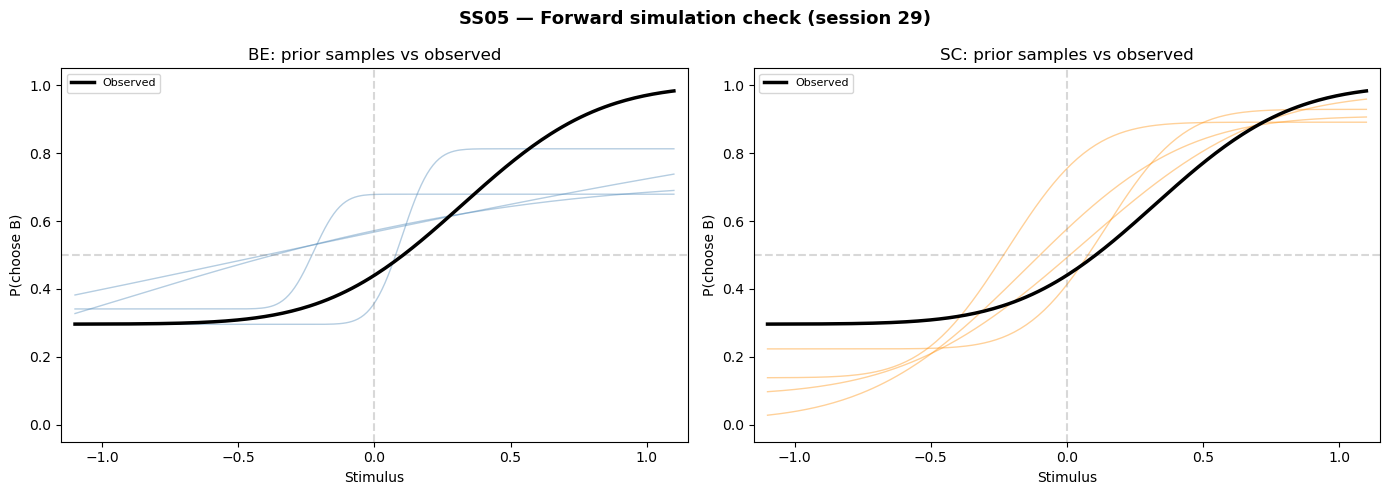

✓ If simulated curves span a range around the observed curve, the models
  and stimulus sequence are working. If all flat at 0.5 → check BURN_IN.


In [71]:
# %% — 4b.1 Forward simulation sanity check
# ───────────────────────────────────────────────────────────────────────
# Before any SBI: just run each model with a few parameter samples from
# the prior and check that simulated behaviour looks plausible.

print("=" * 60)
print("4b.1  Forward simulation check")
print("=" * 60)

# Pick one training session for quick checks
_check_idx = split['n_train'] // 2  # middle session
_check_idx = split['n_train']-1
_v = ~split['train'].no_response[_check_idx]
_stim = split['train'].stimuli[_check_idx][_v]
_cat = split['train'].categories[_check_idx][_v]
_choice = split['train'].choices[_check_idx][_v]

print(f"Using training session {_check_idx}: {len(_stim)} valid trials")

# Observed psychometric
from behav_utils.analysis.psychometry import fit_psychometric
obs_psych = fit_psychometric(_stim, _choice)
x_fine = np.linspace(-1.1, 1.1, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_type, colour, model_name in [
    (axes[0], ModelType.BE, BE_COLOUR, 'BE'),
    (axes[1], ModelType.SC, SC_COLOUR, 'SC'),
]:
    # Observed
    if obs_psych['success']:
        from behav_utils.analysis.utils import cumulative_gaussian
        y_obs = cumulative_gaussian(
            x_fine, obs_psych['mu'], obs_psych['sigma'],
            obs_psych['lapse_low'], obs_psych['lapse_high'],
        )
        ax.plot(x_fine, y_obs, 'k-', lw=2.5, label='Observed', zorder=10)

    # Simulated with 4 prior samples
    creator = create_be_simulator if model_type == ModelType.BE else create_sc_simulator
    for j in range(4):
        sim = creator(_stim, _cat, stat_names=['accuracy'], burn_in=BURN_IN)
        theta = sim.sample_prior(seed=SEED + j)
        try:
            _, choices_sim = sim.simulate(theta, seed=SEED + j, return_choices=True)
            choices_1d = choices_sim.flatten()
            psych_sim = fit_psychometric(_stim, choices_1d)
            if psych_sim['success']:
                y_sim = cumulative_gaussian(
                    x_fine, psych_sim['mu'], psych_sim['sigma'],
                    psych_sim['lapse_low'], psych_sim['lapse_high'],
                )
                ax.plot(x_fine, y_sim, '-', color=colour, alpha=0.4, lw=1)
        except Exception:
            pass

    ax.axhline(0.5, color='grey', ls='--', alpha=0.3)
    ax.axvline(0, color='grey', ls='--', alpha=0.3)
    ax.set_xlabel('Stimulus')
    ax.set_ylabel('P(choose B)')
    ax.set_title(f'{model_name}: prior samples vs observed')
    ax.legend(fontsize=8)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-0.05, 1.05)

fig.suptitle(f'{test_animal.animal_id} — Forward simulation check (session {_check_idx})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ If simulated curves span a range around the observed curve, the models")
print("  and stimulus sequence are working. If all flat at 0.5 → check BURN_IN.")



4b.2  Observed stats and update matrix

Key stats (session 0 vs session 29):
  accuracy                        first=0.513  last=0.732
  recency                         first=0.149  last=0.302
  win_stay                        first=0.129  last=0.170
  stimulus_sensitivity            first=0.029  last=0.484


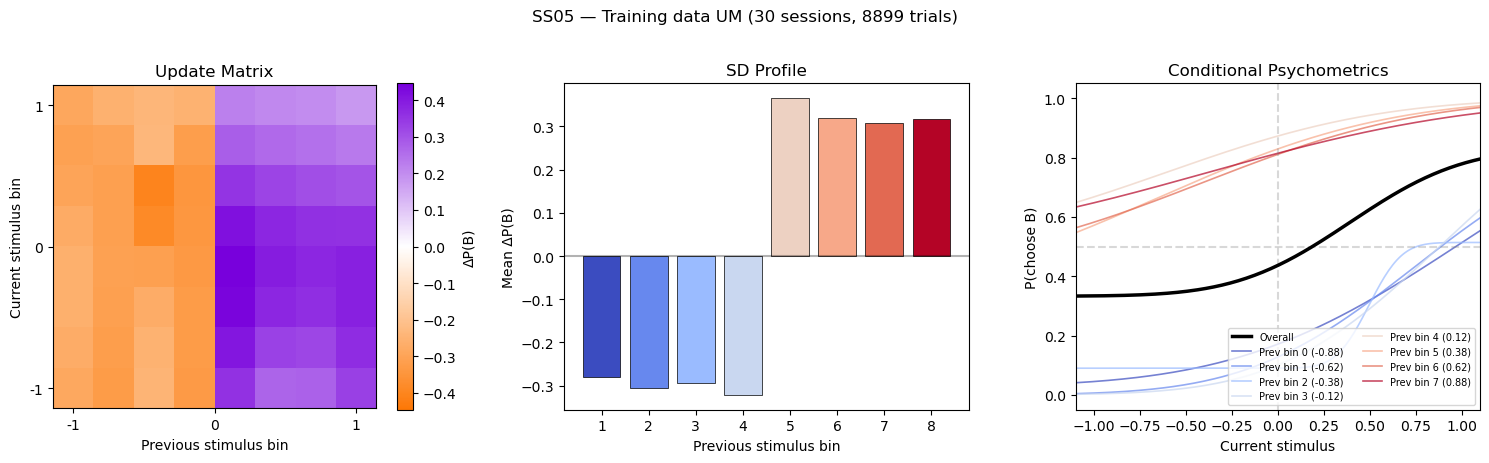

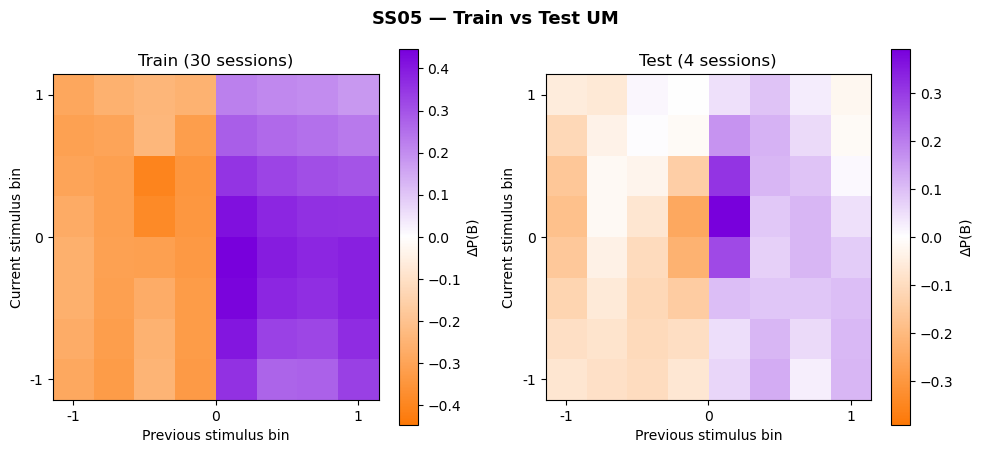

✓ Check: does the UM show a structured pattern (not all grey)?
  Train and test should look qualitatively similar for Uniform expert data.


In [ ]:
# %% — 4b.2  Observed summary stats and update matrix (training data)
print("\n" + "=" * 60)
print("4b.2  Observed stats and update matrix")
print("=" * 60)

# Per-session stats on training data
_obs_dicts = []
for i in range(split['train'].n_sessions):
    v = ~split['train'].no_response[i]
    d = compute_summary_stats(
        split['train'].choices[i][v],
        split['train'].stimuli[i][v],
        split['train'].categories[i][v],
        stat_names=SBI_STAT_NAMES, return_dict=True,
    )
    _obs_dicts.append(d)

# Print a few key stats for first and last training session
print(f"\nKey stats (session 0 vs session {split['n_train']-1}):")
for key in ['accuracy', 'recency', 'win_stay', 'stimulus_sensitivity']:
    if key in _obs_dicts[0]:
        v0 = _obs_dicts[0][key]
        vn = _obs_dicts[-1][key]
        print(f"  {key:30s}  first={v0:.3f}  last={vn:.3f}")

# Pooled training UM
_train_pooled = split['train'].pool()
_train_um, _train_cond, _train_info = compute_update_matrix(
    _train_pooled['stimuli'], _train_pooled['choices'],
    _train_pooled['categories'], n_bins=N_BINS,
)
fig, axes = plot_update_matrix_summary(
    _train_um, _train_cond, info=_train_info,
    title=f'{test_animal.animal_id} — Training data UM '
          f'({split["n_train"]} sessions, {len(_train_pooled["stimuli"])} trials)',
)
plt.show()

# Also show test UM for reference
_test_pooled = split['test'].pool()
_test_um, _test_cond, _test_info = compute_update_matrix(
    _test_pooled['stimuli'], _test_pooled['choices'],
    _test_pooled['categories'], n_bins=N_BINS,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_update_matrix(_train_um, ax=axes[0], title=f'Train ({split["n_train"]} sessions)')
plot_update_matrix(_test_um, ax=axes[1], title=f'Test ({split["n_test"]} sessions)')
fig.suptitle(f'{test_animal.animal_id} — Train vs Test UM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Check: does the UM show a structured pattern (not all grey)?")
print("  Train and test should look qualitatively similar for Uniform expert data.")

In [ ]:
# Quick test on the worst session
v = ~split['train'].no_response[0]
stim = split['train'].stimuli[0][v]
ch = split['train'].choices[0][v]
print(f"Session 0: {len(stim)} trials, accuracy={np.mean(ch == split['train'].categories[0][v]):.3f}")

result = fit_psychometric(stim, ch)
print(f"Success: {result['success']}, mu={result['mu']:.3f}, sigma={result['sigma']:.3f}")
print(f"Optimizer converged: {result.get('optimizer_converged', 'N/A')}")

In [79]:
# %% — 4b.3  Mini SNPE training
print("\n" + "=" * 60)
print(f"4b.3  Mini SNPE training ({DRY_N_SIMS} sims per model)")
print("=" * 60)

DRY_STATS = ['accuracy', 
            #  'psychometric',
             'recency', 'win_stay', 'stimulus_sensitivity']
# Constant links only — 4D theta, fast and reliable
dry_be_links = {
    name: ConstantLink(bounds=DEFAULT_BE_PARAM_LINKS[name].bounds)
    for name in SBIFitter.BE_PARAM_ORDER
}
dry_sc_links = {
    name: ConstantLink(bounds=DEFAULT_SC_PARAM_LINKS[name].bounds)
    for name in SBIFitter.SC_PARAM_ORDER
}

if SBI_AVAILABLE:
    t0 = time.time()

    dry_be_fitter = SBIFitter(
        split['train'], model_type='be', param_links=dry_be_links,
        summary_stats=DRY_STATS, burn_in=BURN_IN,
    )
    dry_sc_fitter = SBIFitter(
        split['train'], model_type='sc', param_links=dry_sc_links,
        summary_stats=DRY_STATS, burn_in=BURN_IN,
    )

    print("Training BE (dry run)...")
    dry_be_result = dry_be_fitter.train(n_simulations=DRY_N_SIMS, seed=SEED)
    print("Training SC (dry run)...")
    dry_sc_result = dry_sc_fitter.train(n_simulations=DRY_N_SIMS, seed=SEED + 1)

    print(f"Done in {(time.time()-t0)/60:.1f} min")
else:
    raise RuntimeError("SBI not available — cannot proceed.")


4b.3  Mini SNPE training (500 sims per model)
Training BE (dry run)...
Round 1/1: Simulating 500 samples...
Round 1/1: Training...
 Neural network successfully converged after 117 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 117
        Best validation performance: -3.3158
        -------------------------
        
Training SC (dry run)...
Round 1/1: Simulating 500 samples...
Round 1/1: Training...
 Neural network successfully converged after 156 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 156
        Best validation performance: -2.5816
        -------------------------
        
Done in 14.5 min


In [ ]:
# Run this BEFORE the posterior sampling cell

# 1. Check for NaN in observed stats
obs = dry_be_fitter.observed_stats
print(f"Observed stats: {len(obs)} dims, {np.sum(np.isnan(obs))} NaN")
nan_idx = np.where(np.isnan(obs))[0]
if len(nan_idx) > 0:
    stat_names = dry_be_fitter.layout.get_expanded_names()  # won't work here
    print(f"NaN positions: {nan_idx}")

# 2. Compare observed range vs simulated range
# Re-simulate a few to see what the simulator produces
test_stats = []
for i in range(20):
    theta = dry_be_fitter._sample_theta_numpy(np.random.default_rng(i))
    s = dry_be_fitter.simulator(theta, seed=i)
    test_stats.append(s)

test_stats = np.array(test_stats)
print(f"\nSimulated stats: {test_stats.shape}, {np.sum(np.isnan(test_stats))} total NaN")

Observed stats: 120 dims, 0 NaN

Simulated stats: (20, 120), 0 total NaN

 Dim       Obs   Sim min   Sim max     Problem
   0     0.513     0.730     0.841  OUT OF RANGE
   1     0.149    -0.089     0.087  OUT OF RANGE
   2     0.129    -0.192     0.154            
   3     0.029     0.521     0.747  OUT OF RANGE
   4     0.463     0.726     0.842  OUT OF RANGE
   5     0.058    -0.072     0.108            
   6     0.064    -0.042     0.145            
   7     0.005     0.531     0.718  OUT OF RANGE
   8     0.566     0.772     0.871  OUT OF RANGE
   9     0.222     0.190     0.401            
  10     0.120     0.185     0.480  OUT OF RANGE
  11     0.116     0.612     0.776  OUT OF RANGE
  12     0.553     0.772     0.864  OUT OF RANGE
  13     0.274     0.030     0.227  OUT OF RANGE
  14     0.196     0.043     0.274            
  15     0.106     0.599     0.770  OUT OF RANGE
  16     0.545     0.755     0.871  OUT OF RANGE
  17     0.294     0.040     0.281  OUT OF RANGE
  18   


4b.4  Parameter posteriors (rough, from dry run)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

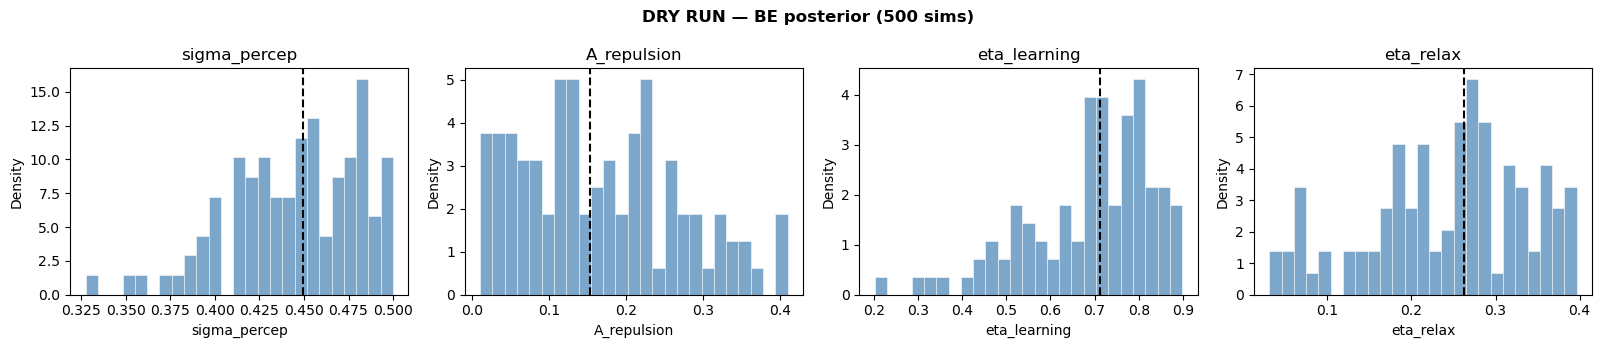

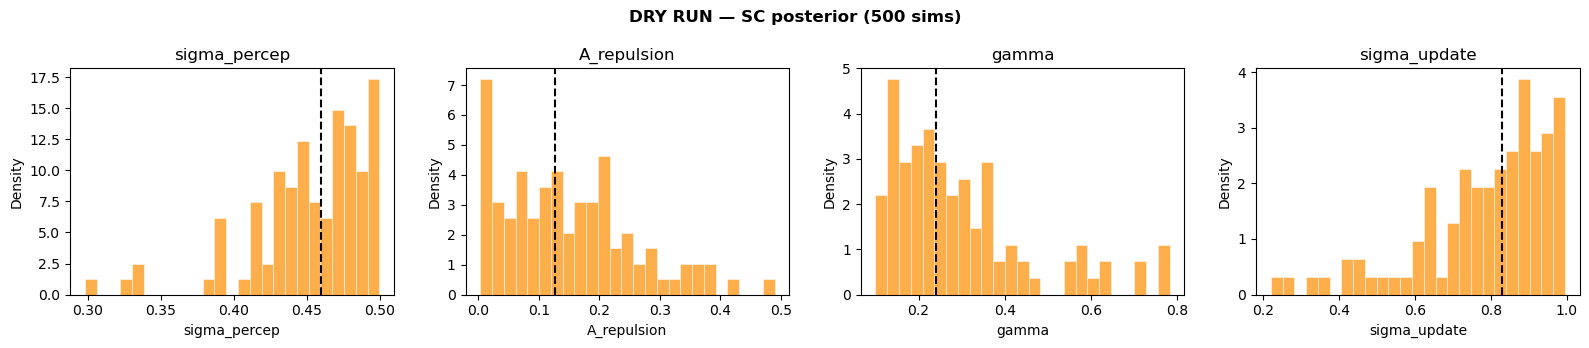

✓ Posteriors will be wide/noisy — that's expected with 500 sims.
  Check: are they in plausible ranges? Not all piled at the bounds?


In [81]:
# %% — 4b.4  Parameter posteriors (dry run)
print("\n" + "=" * 60)
print("4b.4  Parameter posteriors (rough, from dry run)")
print("=" * 60)

dry_be_traj = dry_be_fitter.extract_trajectories(dry_be_result, n_samples=DRY_N_POSTERIOR)
dry_sc_traj = dry_sc_fitter.extract_trajectories(dry_sc_result, n_samples=DRY_N_POSTERIOR)

for mname, traj, order, colour in [
    ('BE', dry_be_traj, SBIFitter.BE_PARAM_ORDER, BE_COLOUR),
    ('SC', dry_sc_traj, SBIFitter.SC_PARAM_ORDER, SC_COLOUR),
]:
    npar = len(order)
    fig, axes = plt.subplots(1, npar, figsize=(4 * npar, 3.5))
    if npar == 1:
        axes = [axes]

    for i, pn in enumerate(order):
        ax = axes[i]
        t = traj[pn]
        si = t['session_indices']

        if t['link_type'] == 'constant':
            ax.hist(t['samples'], bins=25, color=colour, alpha=0.7,
                    density=True, edgecolor='white', linewidth=0.5)
            ax.axvline(t['median'], color='k', ls='--', lw=1.5)
            ax.set_xlabel(pn)
            ax.set_ylabel('Density')
        else:
            ax.fill_between(si, t['ci_low'], t['ci_high'],
                            color=colour, alpha=0.2)
            ax.plot(si, t['median'], '-', color=colour, lw=2)
            ax.set_xlabel('Session')
            ax.set_ylabel(pn)
        ax.set_title(pn)

    fig.suptitle(f'DRY RUN — {mname} posterior ({DRY_N_SIMS} sims)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("✓ Posteriors will be wide/noisy — that's expected with 500 sims.")
print("  Check: are they in plausible ranges? Not all piled at the bounds?")


4b.5  Posterior predictive check (dry run)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

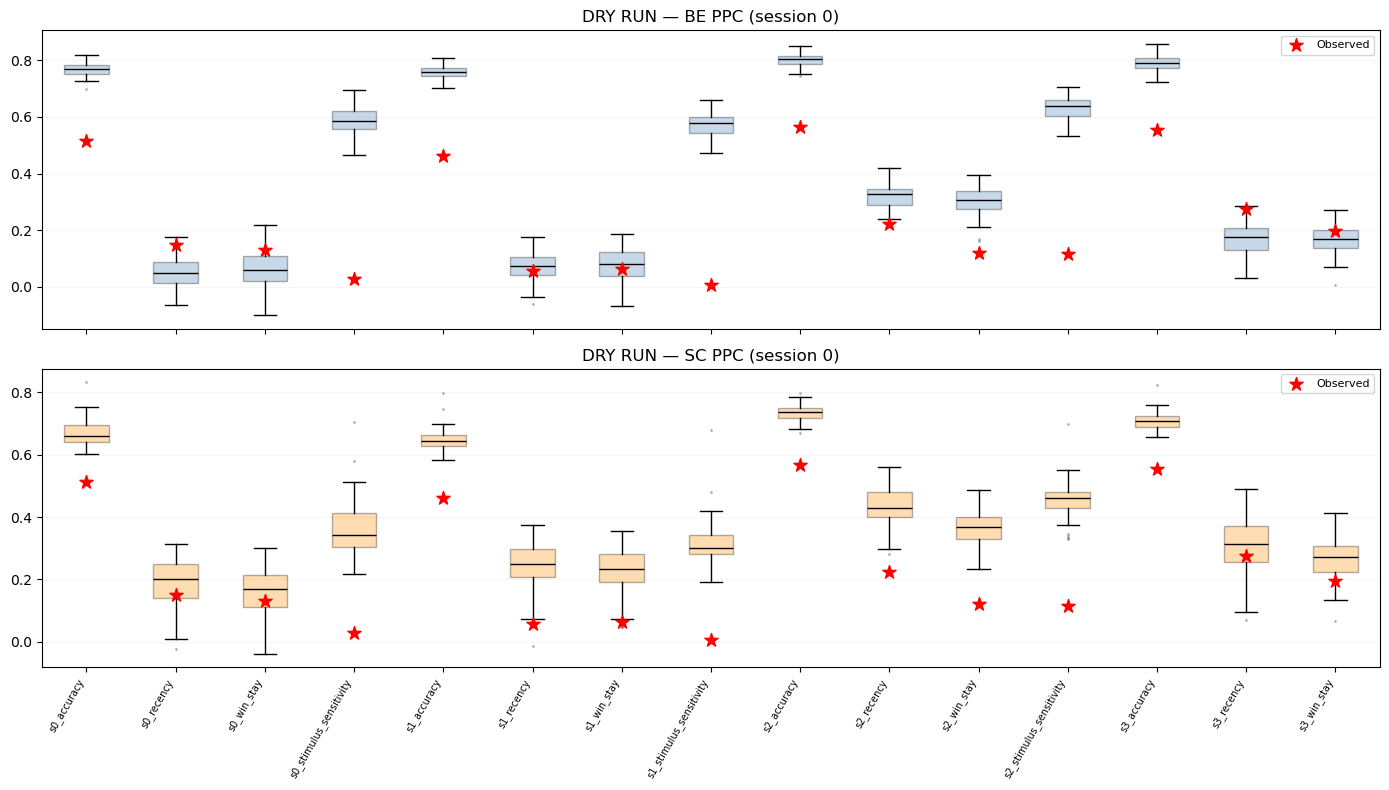

✓ Red stars (observed) should roughly fall within box whiskers.
  Systematic offsets → model or stat computation issue.


In [82]:
# %% — 4b.5  Posterior predictive check (dry run)
print("\n" + "=" * 60)
print("4b.5  Posterior predictive check (dry run)")
print("=" * 60)

dry_be_ppc = dry_be_fitter.posterior_predictive_check(dry_be_result, n_simulations=50)
dry_sc_ppc = dry_sc_fitter.posterior_predictive_check(dry_sc_result, n_simulations=50)

n_show = min(n_dims_per_session, 15)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, ppc, colour, nm in [
    (axes[0], dry_be_ppc, BE_COLOUR, 'BE'),
    (axes[1], dry_sc_ppc, SC_COLOUR, 'SC'),
]:
    if len(ppc['simulated']) == 0:
        ax.text(0.5, 0.5, f'{nm}: no valid sims',
                transform=ax.transAxes, ha='center')
        continue

    pred = ppc['simulated'][:, :n_show]
    obs = ppc['observed'][:n_show]

    ax.boxplot(pred, positions=np.arange(n_show), widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor=colour, alpha=0.3),
               medianprops=dict(color='black'),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.scatter(np.arange(n_show), obs, marker='*', s=100,
               color='red', zorder=5, label='Observed')
    ax.set_title(f'DRY RUN — {nm} PPC (session 0)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.1, axis='y')

axes[-1].set_xticks(np.arange(n_show))
axes[-1].set_xticklabels(
    dry_be_ppc['stat_names'][:n_show], rotation=60, ha='right', fontsize=7,
)
plt.tight_layout()
plt.show()

print("✓ Red stars (observed) should roughly fall within box whiskers.")
print("  Systematic offsets → model or stat computation issue.")


4b.6  Held-out evaluation (dry run)


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


DRY RUN — Session-level holdout (4 sessions):
                         Stat MSE     UM MSE
  BE                       0.2278    0.05890
  SC                       0.1132    0.01233


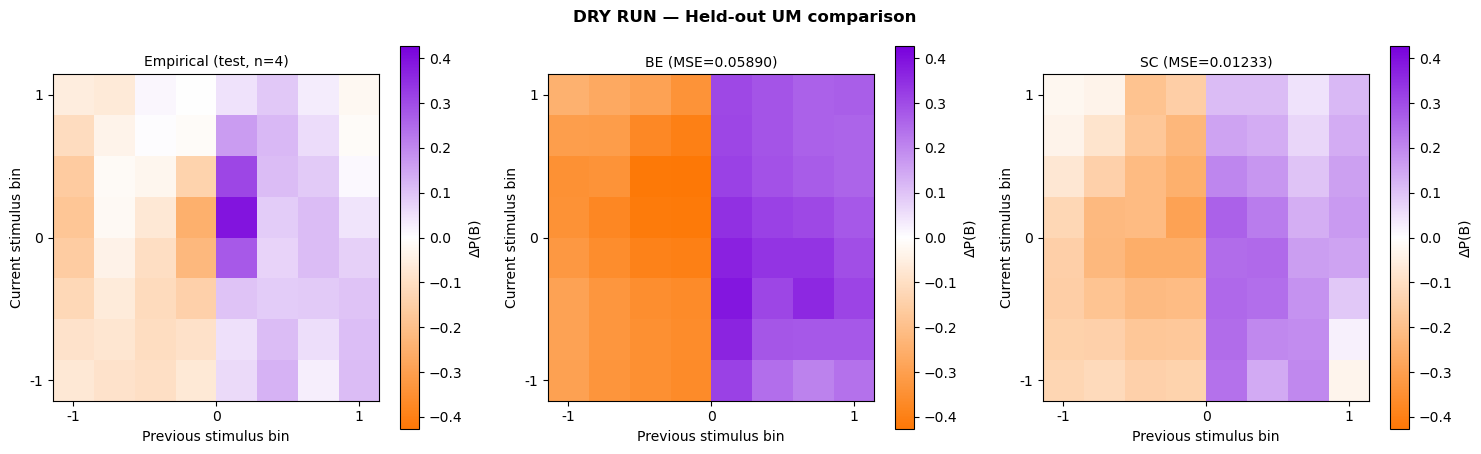


✓ Numbers will be noisy from 500 sims, but the plot structure is final.
  Check: is the UM comparison layout what you want?


In [84]:
# %% — 4b.6  Held-out session evaluation (dry run)
print("\n" + "=" * 60)
print("4b.6  Held-out evaluation (dry run)")
print("=" * 60)

dry_be_eval = evaluate_on_heldout_sessions(
    dry_be_fitter, dry_be_result, split['test'],
    SBI_STAT_NAMES, n_sim_reps=DRY_N_SIM_REPS,
)
dry_sc_eval = evaluate_on_heldout_sessions(
    dry_sc_fitter, dry_sc_result, split['test'],
    SBI_STAT_NAMES, n_sim_reps=DRY_N_SIM_REPS,
)

print(f"\nDRY RUN — Session-level holdout ({split['n_test']} sessions):")
print(f"  {'':20s} {'Stat MSE':>10s} {'UM MSE':>10s}")
print(f"  {'BE':20s} {dry_be_eval['mean_stat_mse']:10.4f} {dry_be_eval['um_mse']:10.5f}")
print(f"  {'SC':20s} {dry_sc_eval['mean_stat_mse']:10.4f} {dry_sc_eval['um_mse']:10.5f}")

# UM comparison plot
if dry_be_eval['sim_mean_um'] is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    vlim = max(
        np.nanmax(np.abs(dry_be_eval['obs_um'])),
        np.nanmax(np.abs(dry_be_eval['sim_mean_um'])),
        np.nanmax(np.abs(dry_sc_eval['sim_mean_um']))
            if dry_sc_eval['sim_mean_um'] is not None else 0,
    )

    for ax, um, title in [
        (axes[0], dry_be_eval['obs_um'],
         f'Empirical (test, n={split["n_test"]})'),
        (axes[1], dry_be_eval['sim_mean_um'],
         f'BE (MSE={dry_be_eval["um_mse"]:.5f})'),
        (axes[2], dry_sc_eval['sim_mean_um'],
         f'SC (MSE={dry_sc_eval["um_mse"]:.5f})'),
    ]:
        if um is not None:
            plot_update_matrix(um, ax=ax, vmin=-vlim, vmax=vlim)
        ax.set_title(title, fontsize=10)

    fig.suptitle(f'DRY RUN — Held-out UM comparison', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("  (No valid simulated UMs — may need more reps or check burn-in)")

print("\n✓ Numbers will be noisy from 500 sims, but the plot structure is final.")
print("  Check: is the UM comparison layout what you want?")


4b.7  Within-session holdout (dry run)


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  BE mean MSE: 0.15765
  SC mean MSE: 0.14069


/var/folders/l1/l742y54d4hx05wj38054vs_r0000gn/T/ipykernel_86082/2007577058.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([b, s], labels=['BE', 'SC'], widths=0.3)


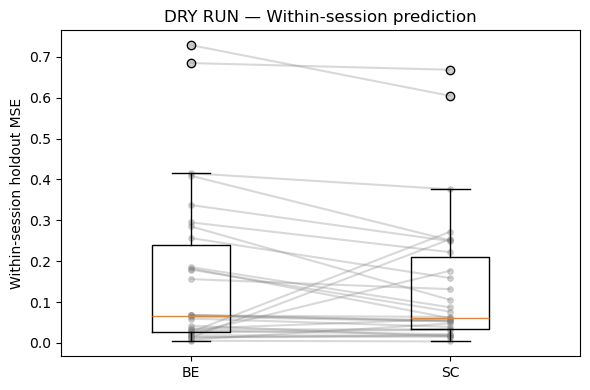

✓ Check: does the paired plot format work for your purposes?


In [88]:
# %% — 4b.7  Within-session holdout (dry run)
if split['train_heldout_trials'] is not None:
    print("\n" + "=" * 60)
    print("4b.7  Within-session holdout (dry run)")
    print("=" * 60)

    dry_be_sp = dry_be_fitter.extract_session_params(dry_be_result)
    dry_sc_sp = dry_sc_fitter.extract_session_params(dry_sc_result)

    dry_be_ws, dry_sc_ws = [], []
    _eval_stats = ['accuracy', 'psychometric']

    for i, ho in enumerate(split['train_heldout_trials']):
        if len(ho['stimuli']) < 20:
            continue
        obs = compute_summary_stats(
            ho['choices'], ho['stimuli'], ho['categories'],
            stat_names=_eval_stats, return_dict=False,
        )
        for params, mt, mse_list in [
            (dry_be_sp[i], ModelType.BE, dry_be_ws),
            (dry_sc_sp[i], ModelType.SC, dry_sc_ws),
        ]:
            cr = create_be_simulator if mt == ModelType.BE else create_sc_simulator
            sim = cr(ho['stimuli'], ho['categories'], fixed_params=params,
                     stat_names=_eval_stats, burn_in=BURN_IN)
            preds = []
            for r in range(10):
                try:
                    s = sim.simulate(sim.sample_prior(seed=r), seed=r)
                    if not np.any(np.isnan(s)):
                        preds.append(s)
                except Exception:
                    pass
            if preds:
                mse_list.append(np.nanmean((np.nanmean(preds, axis=0) - obs)**2))
            else:
                mse_list.append(np.nan)

    print(f"  BE mean MSE: {np.nanmean(dry_be_ws):.5f}")
    print(f"  SC mean MSE: {np.nanmean(dry_sc_ws):.5f}")

    fig, ax = plt.subplots(figsize=(6, 4))
    valid_m = ~(np.isnan(dry_be_ws) | np.isnan(dry_sc_ws))
    b = np.array(dry_be_ws)[valid_m]
    s = np.array(dry_sc_ws)[valid_m]
    for j in range(len(b)):
        ax.plot([1, 2], [b[j], s[j]], 'o-', color='grey', alpha=0.3, markersize=4)
    ax.boxplot([b, s], labels=['BE', 'SC'], widths=0.3)
    ax.set_ylabel('Within-session holdout MSE')
    ax.set_title(f'DRY RUN — Within-session prediction')
    plt.tight_layout()
    plt.show()

    print("✓ Check: does the paired plot format work for your purposes?")

In [89]:
# %% — 4b.8  Summary
print("\n" + "=" * 60)
print("4b.8  DRY RUN COMPLETE")
print("=" * 60)
print(f"""
All plots above are what you'll get from the real pipeline.
The numbers are unreliable (only {DRY_N_SIMS} sims) but the structure is final.

Checklist before proceeding to §5:
  [ ] Forward sim check: simulated psychometrics span a reasonable range
  [ ] Observed UM: structured pattern, not all grey/NaN
  [ ] Train vs test UM: qualitatively similar
  [ ] Parameter posteriors: in plausible ranges, not at bounds
  [ ] PPC: observed stats roughly within predicted range
  [ ] Held-out UM comparison: 3-panel layout is what you want
  [ ] Within-session holdout: paired plot format is useful
  [ ] No errors or unexpected NaNs

If everything looks good → proceed to §5 with full N_SBI_SIMS.
If plots need changes → edit the plotting code above, re-run dry run.
If stats look wrong → check STAT_PRESET, BURN_IN, parameter bounds.
""")



4b.8  DRY RUN COMPLETE

All plots above are what you'll get from the real pipeline.
The numbers are unreliable (only 500 sims) but the structure is final.

Checklist before proceeding to §5:
  [ ] Forward sim check: simulated psychometrics span a reasonable range
  [ ] Observed UM: structured pattern, not all grey/NaN
  [ ] Train vs test UM: qualitatively similar
  [ ] Parameter posteriors: in plausible ranges, not at bounds
  [ ] PPC: observed stats roughly within predicted range
  [ ] Held-out UM comparison: 3-panel layout is what you want
  [ ] Within-session holdout: paired plot format is useful
  [ ] No errors or unexpected NaNs

If everything looks good → proceed to §5 with full N_SBI_SIMS.
If plots need changes → edit the plotting code above, re-run dry run.
If stats look wrong → check STAT_PRESET, BURN_IN, parameter bounds.



---
## 5. Multi-session SBIFitter: train BE and SC

In [54]:
if SBI_AVAILABLE:
    print("Training BE...")
    t0 = time.time()
    be_result = be_fitter.train(n_simulations=N_SBI_SIMS, seed=SEED)
    print(f"  Done in {(time.time()-t0)/60:.1f} min")

    print("\nTraining SC...")
    t0 = time.time()
    sc_result = sc_fitter.train(n_simulations=N_SBI_SIMS, seed=SEED + 1)
    print(f"  Done in {(time.time()-t0)/60:.1f} min")
else:
    print("SBI not available.")

Training BE...
Round 1/1: Simulating 10000 samples...


KeyboardInterrupt: 

---
## 6. Posterior parameter distributions

In [ ]:
if SBI_AVAILABLE:
    be_traj = be_fitter.extract_trajectories(be_result, n_samples=N_POSTERIOR_SAMPLES)
    sc_traj = sc_fitter.extract_trajectories(sc_result, n_samples=N_POSTERIOR_SAMPLES)

    for mname, traj, order in [
        ('BE', be_traj, SBIFitter.BE_PARAM_ORDER),
        ('SC', sc_traj, SBIFitter.SC_PARAM_ORDER),
    ]:
        print(f"\n{mname} posterior:")
        for pn in order:
            t = traj[pn]
            if t['link_type'] == 'constant':
                print(f"  {pn}: {t['median']:.3f} [{t['ci_low']:.3f}, {t['ci_high']:.3f}]")
            else:
                m = t['median']
                print(f"  {pn}: trajectory [{m[0]:.3f} ... {m[-1]:.3f}], "
                      f"range [{m.min():.3f}, {m.max():.3f}]")

In [ ]:
if SBI_AVAILABLE:
    for mname, traj, order, colour in [
        ('BE', be_traj, SBIFitter.BE_PARAM_ORDER, BE_COLOUR),
        ('SC', sc_traj, SBIFitter.SC_PARAM_ORDER, SC_COLOUR),
    ]:
        npar = len(order)
        fig, axes = plt.subplots(1, npar, figsize=(4 * npar, 3.5))
        if npar == 1:
            axes = [axes]

        for i, pn in enumerate(order):
            ax = axes[i]
            t = traj[pn]
            si = t['session_indices']

            if t['link_type'] == 'constant':
                ax.hist(t['samples'], bins=40, color=colour, alpha=0.7,
                        density=True, edgecolor='white', linewidth=0.5)
                ax.axvline(t['median'], color='k', ls='--', lw=1.5)
                ax.set_xlabel(pn); ax.set_ylabel('Density')
            else:
                ax.fill_between(si, t['ci_low'], t['ci_high'],
                                color=colour, alpha=0.2)
                ax.plot(si, t['median'], '-', color=colour, lw=2)
                ax.set_xlabel('Session'); ax.set_ylabel(pn)
            ax.set_title(pn)

        fig.suptitle(f'{test_animal.animal_id} — {mname} posterior',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

---
## 7. Held-out evaluation

### 7a. Session-level holdout

Use posterior parameter estimates (from last training session) to simulate
on held-out session stimuli. Compare both summary stats and update matrices.

In [ ]:
if SBI_AVAILABLE:
    print("Evaluating on held-out sessions...")
    be_eval = evaluate_on_heldout_sessions(
        be_fitter, be_result, split['test'], SBI_STAT_NAMES, n_sim_reps=50,
    )
    sc_eval = evaluate_on_heldout_sessions(
        sc_fitter, sc_result, split['test'], SBI_STAT_NAMES, n_sim_reps=50,
    )

    print(f"\nSession-level holdout ({split['n_test']} sessions):")
    print(f"  {'':20s} {'Stat MSE':>10s} {'UM MSE':>10s}")
    print(f"  {'BE':20s} {be_eval['mean_stat_mse']:10.4f} {be_eval['um_mse']:10.5f}")
    print(f"  {'SC':20s} {sc_eval['mean_stat_mse']:10.4f} {sc_eval['um_mse']:10.5f}")
    print(f"  Winner (stat): {'BE' if be_eval['mean_stat_mse'] < sc_eval['mean_stat_mse'] else 'SC'}")
    print(f"  Winner (UM):   {'BE' if be_eval['um_mse'] < sc_eval['um_mse'] else 'SC'}")

In [ ]:
# Update matrix comparison on held-out data
if SBI_AVAILABLE and be_eval['sim_mean_um'] is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    vlim = max(
        np.nanmax(np.abs(be_eval['obs_um'])),
        np.nanmax(np.abs(be_eval['sim_mean_um'])),
        np.nanmax(np.abs(sc_eval['sim_mean_um'])) if sc_eval['sim_mean_um'] is not None else 0,
    )
    for ax, um, title in [
        (axes[0], be_eval['obs_um'],
         f'Empirical (test, n={split["n_test"]})'),
        (axes[1], be_eval['sim_mean_um'],
         f'BE (UM MSE={be_eval["um_mse"]:.5f})'),
        (axes[2], sc_eval['sim_mean_um'],
         f'SC (UM MSE={sc_eval["um_mse"]:.5f})'),
    ]:
        if um is not None:
            plot_update_matrix(um, ax=ax, vmin=-vlim, vmax=vlim)
        ax.set_title(title, fontsize=10)

    fig.suptitle(f'{test_animal.animal_id} — Held-out UM Comparison',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 7b. Within-session holdout

For each training session, the last `WITHIN_SESSION_HOLDOUT` trials were
excluded. Here we evaluate on those held-out trials.

In [ ]:
if SBI_AVAILABLE and split['train_heldout_trials'] is not None:
    be_sp = be_fitter.extract_session_params(be_result)
    sc_sp = sc_fitter.extract_session_params(sc_result)

    be_ws, sc_ws = [], []
    eval_stats = ['accuracy', 'psychometric']  # lightweight for within-session

    for i, ho in enumerate(split['train_heldout_trials']):
        if len(ho['stimuli']) < 20:
            continue
        obs = compute_summary_stats(
            ho['choices'], ho['stimuli'], ho['categories'],
            stat_names=eval_stats, return_dict=False,
        )
        for params, mt, mse_list in [
            (be_sp[i], ModelType.BE, be_ws), (sc_sp[i], ModelType.SC, sc_ws),
        ]:
            cr = create_be_simulator if mt == ModelType.BE else create_sc_simulator
            sim = cr(ho['stimuli'], ho['categories'], fixed_params=params,
                     stat_names=eval_stats, burn_in=BURN_IN)
            preds = []
            for r in range(30):
                try:
                    s = sim.simulate(sim.sample_prior(seed=r), seed=r)
                    if not np.any(np.isnan(s)):
                        preds.append(s)
                except Exception:
                    pass
            if preds:
                mse_list.append(np.nanmean((np.nanmean(preds, axis=0) - obs)**2))
            else:
                mse_list.append(np.nan)

    print(f"Within-session holdout (last {WITHIN_SESSION_HOLDOUT} trials):")
    print(f"  BE mean MSE: {np.nanmean(be_ws):.5f}")
    print(f"  SC mean MSE: {np.nanmean(sc_ws):.5f}")

    fig, ax = plt.subplots(figsize=(6, 4))
    valid_mask = ~(np.isnan(be_ws) | np.isnan(sc_ws))
    b, s = np.array(be_ws)[valid_mask], np.array(sc_ws)[valid_mask]
    for j in range(len(b)):
        ax.plot([0, 1], [b[j], s[j]], 'o-', color='grey', alpha=0.3, markersize=4)
    ax.boxplot([b, s], labels=['BE', 'SC'], widths=0.3)
    ax.set_ylabel('Within-session holdout MSE')
    ax.set_title(f'{test_animal.animal_id} — Within-session prediction')
    plt.tight_layout()
    plt.show()

elif split['train_heldout_trials'] is None:
    print("Within-session holdout disabled (set WITHIN_SESSION_HOLDOUT > 0).")

---
## 8. Posterior predictive check (training data)

In [ ]:
if SBI_AVAILABLE:
    be_ppc = be_fitter.posterior_predictive_check(be_result, n_simulations=200)
    sc_ppc = sc_fitter.posterior_predictive_check(sc_result, n_simulations=200)

    for nm, ppc in [('BE', be_ppc), ('SC', sc_ppc)]:
        p = ppc['p_values']
        cal = np.mean((p > 0.05) & (p < 0.95))
        print(f"{nm}: {cal:.0%} well-calibrated stats "
              f"({len(ppc['simulated'])}/{200} valid sims)")

In [ ]:
if SBI_AVAILABLE and len(be_ppc['simulated']) > 0:
    n_show = min(n_dims_per_session, 15)
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    for ax, ppc, colour, nm in [
        (axes[0], be_ppc, BE_COLOUR, 'BE'),
        (axes[1], sc_ppc, SC_COLOUR, 'SC'),
    ]:
        if len(ppc['simulated']) == 0:
            ax.text(0.5, 0.5, f'{nm}: no valid sims',
                    transform=ax.transAxes, ha='center')
            continue
        pred = ppc['simulated'][:, :n_show]
        obs = ppc['observed'][:n_show]
        ax.boxplot(pred, positions=np.arange(n_show), widths=0.5,
                   patch_artist=True,
                   boxprops=dict(facecolor=colour, alpha=0.3),
                   medianprops=dict(color='black'),
                   flierprops=dict(marker='.', markersize=2, alpha=0.3))
        ax.scatter(np.arange(n_show), obs, marker='*', s=100,
                   color='red', zorder=5, label='Observed')
        ax.set_title(f'{nm}: PPC (session 0)')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.1, axis='y')

    axes[-1].set_xticks(np.arange(n_show))
    axes[-1].set_xticklabels(
        be_ppc['stat_names'][:n_show], rotation=60, ha='right', fontsize=7,
    )
    plt.tight_layout()
    plt.show()

---
## 9. Per-session quick comparison (optional)

Independent single-session fits using the lower-level `Simulator`. Faster
than SBIFitter; useful as a sanity check before committing to the full fit.

**Skip this section if multi-session results look reasonable.**

In [ ]:
RUN_PER_SESSION = False   # Set True to run
N_SIMS_QUICK = 5_000
QUICK_STATS = ['accuracy', 'psychometric', 'recency', 'win_stay',
               'stimulus_sensitivity']

In [ ]:
if SBI_AVAILABLE and RUN_PER_SESSION:
    ps_results = []
    for i in range(split['train'].n_sessions):
        v = ~split['train'].no_response[i]
        stim = split['train'].stimuli[i][v]
        cat = split['train'].categories[i][v]
        ch = split['train'].choices[i][v]
        obs = compute_summary_stats(ch, stim, cat, stat_names=QUICK_STATS, return_dict=False)

        ri = {'session': i}
        for mt in [ModelType.BE, ModelType.SC]:
            cr = create_be_simulator if mt == ModelType.BE else create_sc_simulator
            sim = cr(stim, cat, stat_names=QUICK_STATS, burn_in=BURN_IN)
            prior = get_sbi_prior(sim)
            sbi_sim = wrap_for_sbi(sim)

            theta = prior.sample((N_SIMS_QUICK,))
            x = torch.stack([sbi_sim(t) for t in theta])
            ok = ~torch.any(torch.isnan(x), dim=1)

            inf = SNPE(prior=prior)
            inf.append_simulations(theta[ok], x[ok])
            post = inf.build_posterior(inf.train())

            xo = torch.tensor(obs, dtype=torch.float32)
            ps = post.sample((100,), x=xo)
            preds = [sbi_sim(t).numpy() for t in ps
                     if not torch.any(torch.isnan(sbi_sim(t)))]
            pm = np.nanmean(preds, axis=0) if preds else np.full_like(obs, np.nan)
            ri[f'{mt.value}_mse'] = np.nanmean((pm - obs) ** 2)

        ps_results.append(ri)
        print(f"  Session {i}: BE={ri['be_mse']:.4f}, SC={ri['sc_mse']:.4f}")

    ps_df = pd.DataFrame(ps_results)
    ps_df['winner'] = np.where(ps_df['be_mse'] < ps_df['sc_mse'], 'BE', 'SC')
    print(f"\nPer-session tally: {ps_df['winner'].value_counts().to_dict()}")
elif not RUN_PER_SESSION:
    print("Skipped (set RUN_PER_SESSION = True to enable).")

---
## 10. Multi-animal loop

In [ ]:
def fit_and_compare_animal(
    animal, stage, distribution, holdout_fraction, within_session_holdout,
    stat_names, be_links, sc_links, n_sbi_sims, burn_in, seed,
) -> Optional[Dict]:
    aid = animal.animal_id
    print(f"\n{'#'*60}\n# {aid}\n{'#'*60}")

    try:
        sp = split_fitting_data(
            animal, stage, distribution,
            holdout_fraction, within_session_holdout, MIN_VALID_TRIALS,
        )
    except ValueError as e:
        print(f"  Skipping: {e}")
        return None

    print(f"  Train: {sp['n_train']}, Test: {sp['n_test']}")

    bf = SBIFitter(sp['train'], 'be', be_links, stat_names, burn_in)
    sf = SBIFitter(sp['train'], 'sc', sc_links, stat_names, burn_in)
    br = bf.train(n_simulations=n_sbi_sims, seed=seed)
    sr = sf.train(n_simulations=n_sbi_sims, seed=seed + 1)

    be_ev = evaluate_on_heldout_sessions(bf, br, sp['test'], stat_names, 30)
    sc_ev = evaluate_on_heldout_sessions(sf, sr, sp['test'], stat_names, 30)

    r = {
        'animal_id': aid, 'n_train': sp['n_train'], 'n_test': sp['n_test'],
        'be_stat_mse': be_ev['mean_stat_mse'], 'sc_stat_mse': sc_ev['mean_stat_mse'],
        'be_um_mse': be_ev['um_mse'], 'sc_um_mse': sc_ev['um_mse'],
        'stat_winner': 'BE' if be_ev['mean_stat_mse'] < sc_ev['mean_stat_mse'] else 'SC',
        'um_winner': 'BE' if be_ev['um_mse'] < sc_ev['um_mse'] else 'SC',
    }
    print(f"  Stat: BE={r['be_stat_mse']:.4f} SC={r['sc_stat_mse']:.4f} → {r['stat_winner']}")
    print(f"  UM:   BE={r['be_um_mse']:.5f} SC={r['sc_um_mse']:.5f} → {r['um_winner']}")
    return r

In [ ]:
all_results = []
if SBI_AVAILABLE:
    for animal in animals_to_fit:
        r = fit_and_compare_animal(
            animal, STAGE, DISTRIBUTION,
            HOLDOUT_FRACTION, WITHIN_SESSION_HOLDOUT,
            SBI_STAT_NAMES, be_links, sc_links,
            N_SBI_SIMS, BURN_IN, SEED,
        )
        if r is not None:
            all_results.append(r)
    print(f"\n{'='*60}\nCompleted {len(all_results)} animals")

---
## 11. Group summary

In [ ]:
if all_results:
    df = pd.DataFrame(all_results)
    print(df.to_string(index=False))
    print(f"\nStat winner: {df['stat_winner'].value_counts().to_dict()}")
    print(f"UM winner:   {df['um_winner'].value_counts().to_dict()}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, bc, sc, title in [
        (axes[0], 'be_stat_mse', 'sc_stat_mse', 'Summary stat MSE'),
        (axes[1], 'be_um_mse', 'sc_um_mse', 'Update matrix MSE'),
    ]:
        ax.scatter(df[bc], df[sc], s=60, alpha=0.7)
        for _, row in df.iterrows():
            ax.annotate(row['animal_id'], (row[bc], row[sc]), fontsize=7)
        lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
        ax.plot([0, lim], [0, lim], 'k--', alpha=0.3)
        ax.set_xlabel('BE'); ax.set_ylabel('SC'); ax.set_title(title)
        ax.set_aspect('equal')
    fig.suptitle('Held-out Test Error', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Notes

**Troubleshooting**
- High NaN rate in §4 → increase `BURN_IN` or tighten parameter bounds.
- Training takes hours → switch `STAT_PRESET` to `'mid'` or `'core'`.
- Posteriors look identical → stats lack discriminative power. Add
  `'update_matrix'` or `'conditional_psychometric'`.
- Within-session holdout shows no difference → expected if both models
  fit expert behaviour equally; the UM pattern is the discriminant.

**Interpretation**
- **Stat MSE**: overall goodness-of-fit on held-out sessions.
- **UM MSE**: model *identity* — BE and SC make opposite predictions
  about how easy/difficult previous trials influence subsequent boundary
  trials (manuscript Fig. 4B).
- **Session-level holdout**: tests temporal generalisation (relevant for
  PPC dispensability — if the model fails after a distribution shift, that
  is informative).
- **Within-session holdout**: tests within-session prediction. Less
  discriminative but verifies overall fit quality.